# Experiments of separate ConVAEs only

## ⚠️ Dependency Note

This notebook assumes that `01_setup_data.ipynb` has been executed
in the same Python session.

The setup notebook defines:
- Data loading 
- Metadata information (variable types and levels)
- Shared configuration variables

If running this notebook independently, please execute
`01_setup_data.ipynb` first.

In [0]:
# experiment of using ConVAE only
#device = 'cuda:0'
## preprocess the dataset
df_meta = fit_metadata(df = mcrpc_data, numerical_var = numerical_var, binary_var = binary_var, categorical_var = categorical_var, integer_numerical_var = numerical_var)
mcrpc_preprocessed = preprocess_with_meta(df = mcrpc_data, meta = df_meta)
# Create binary_cols by excluding "hosp_ed_any" from binary_var
#binary_cols_filtered = [col for col in binary_var if col != "hosp_ed_any"]
# get the variable bounds
var_bounds = {
    var: {
        "lower": mcrpc_preprocessed[var].min(),
        "upper": mcrpc_preprocessed[var].max()
    }
    for var in numerical_var
}

print(var_bounds)

{'age': {'lower': -4.537034293904426, 'upper': 1.8896540912240647}, 'Charlson': {'lower': -0.8676660202605704, 'upper': 6.151929965063899}}


In [0]:
## Part 1: test overlap control
def overlap_fn(X, index):
    Abiraterone_prev = index.slice(X, "Abiraterone_prev")
    return 2*(2*Abiraterone_prev-1)
model_X = conVAE(df=mcrpc_preprocessed,
           Xnames = ["exp"],
           Ynames = X.columns.tolist(),
           treatment_cols = ["exp"],
           binary_cols=binary_var,  
           categorical_cols=categorical_var,    
           categorical_dims=unique_levels,
           var_bounds = {},
           latent_dim=18,  # latent space dimensions
           hidden_dim=[64],  # perceptrons in each layer
           batch_size=10,
           potential_outcome=False,
           #treatment_effect_fn=lambda x, index: 0.1,  # treatment effect function defined by the user
           #selection_bias_fn=lambda x, t, index: 0,  # selection bias function defined by the user
           effect_rigidity= 1e3,
           bias_rigidity = 1e3,
           kld_rigidity=0.1,
           overlap_weight = 1e1, # 1e2 is good for a constant value of the overlap_target; 1e1 is good for a function of the overlap_target (even if it is constant result); if 1e3, the marginal disributions for varaibles are not similar at all
           #overlap_target= lambda x, index: 5, #this works
           overlap_target= overlap_fn,
           )#.to(device) # model doesn't converge well when overlap_target = 8
model_X.fit_model(accelerator='auto', precision='32-true', max_epochs=1000, limit_train_batches=0.5)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



In [0]:
# Last logged validation loss from the final epoch
last_val_X = model_X.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")

Last val_loss for X: 1.1890467405319214


In [0]:
model_X.fit_bgmm_from_training_latents()
T_tensor = torch.tensor(mcrpc_preprocessed[["exp"]].values, dtype=torch.float32)
X_gen = model_X.generate_bgmm(x = T_tensor)

In [0]:
# the shape of X_gen
X_gen.shape

torch.Size([4098, 18])

In [0]:
overlap_metrics = model_X.overlap_diagnostics(X_gen, T_tensor) 
print("Overlap metrics:", {k: round(v, 4) for k, v in overlap_metrics.items()})

Overlap metrics: {'dec/log_ratio_mean': -0.247, 'dec/log_ratio_std': 1.951, 'dec/target_mean': -0.224, 'dec/target_std': 1.987, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.996, 'ps/auc': 0.889, 'ps/hist_overlap_coeff': 0.242, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


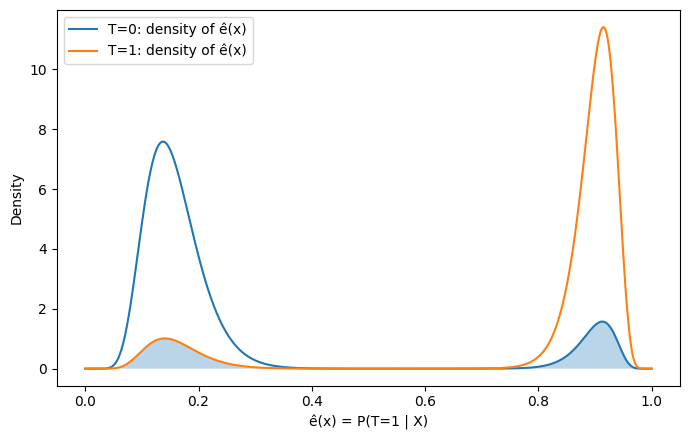

{'overlap_coeff': 0.24189353696098098, 'bw0': 0.3390528490074291, 'bw1': 0.3390528490074291, 'path': None}


In [0]:
# plot the propensity score overlap
def plot_propensity_overlap(
    X_gen,
    T_gen,
    gridsize: int = 600,
    eps: float = 1e-6,
    bw0: float | None = None,
    bw1: float | None = None,
    savepath: str | None = None,
    e_hat_override: np.ndarray | None = None,
    shared_bw = True
):
    '''
    Smooth overlap plot via KDE on logit scale.

    Steps:
      1) Fit ê(x)=P(T=1|X) (or use e_hat_override).
      2) Transform s=ê to u=logit(s), do Gaussian KDE on u∈ℝ for each group T=0/1.
      3) Map back to s-grid with Jacobian: p_S(s) = p_U(logit(s)) / (s*(1-s)).
      4) Overlap coefficient = ∫ min(p0(s), p1(s)) ds on s∈[0,1].

    Returns:
      dict: {'auc', 'overlap_coeff', 'bw0', 'bw1', 'path'}
    '''
    X_np = np.asarray(X_gen, dtype=np.float32)
    T_np = np.asarray(T_gen, dtype=int).reshape(-1)
    if X_np.ndim != 2 or T_np.ndim != 1 or X_np.shape[0] != T_np.shape[0]:
        raise ValueError("Shapes must be X_gen: [N, V], T_gen: [N]")

    # 1) get propensities
    if e_hat_override is None:
        e_hat = fit_logistic_torch(X_np, T_np, max_iter=250)
    else:
        e_hat = np.asarray(e_hat_override, dtype=float).reshape(-1)

    # clip to avoid logit overflow
    e_hat = np.clip(e_hat, eps, 1.0 - eps)
    # we already calculated AUC in overlap_diagnostics() 
    # auc = auc_from_scores(e_hat, T_np)

    # split by treatment
    e0 = e_hat[T_np == 0]
    e1 = e_hat[T_np == 1]
    u0 = np.log(e0) - np.log(1.0 - e0)
    u1 = np.log(e1) - np.log(1.0 - e1)

    # 2) KDE on real line
    grid_s = np.linspace(eps, 1.0 - eps, gridsize)
    grid_u = np.log(grid_s) - np.log(1.0 - grid_s)

    # d0_u, bw0 = _kde_gaussian_R(grid_u, u0, bw=bw0)
    # d1_u, bw1 = _kde_gaussian_R(grid_u, u1, bw=bw1)
    # update 11/10/2025: use a shared bandwidth for both groups when reporting overlap 
    #                    pooled silverman is used to compute bandwidth on the combined logit samples
    if shared_bw:
        u_all = np.concatenate([u0, u1])
        bw = _silverman_bandwidth(u_all)
        d0_u, bw0 = _kde_gaussian_R(grid_u, u0, bw=bw)
        d1_u, bw1 = _kde_gaussian_R(grid_u, u1, bw=bw)
    else:
        d0_u, bw0 = _kde_gaussian_R(grid_u, u0, bw=bw0)
        d1_u, bw0 = _kde_gaussian_R(grid_u, u1, bw=bw1)

    # 3) change of variables back to s in (0,1)
    jac = grid_s * (1.0 - grid_s)
    d0_s = d0_u / (jac + 1e-12)
    d1_s = d1_u / (jac + 1e-12)

    # numeric normalization on [0,1]
    area0 = np.trapz(d0_s, grid_s);  area1 = np.trapz(d1_s, grid_s)
    if area0 > 0: d0_s = d0_s / area0
    if area1 > 0: d1_s = d1_s / area1

    # 4) overlap coefficient
    overlap_coeff = float(np.trapz(np.minimum(d0_s, d1_s), grid_s))

    # plot
    plt.figure(figsize=(7, 4.5))
    plt.plot(grid_s, d0_s, label="T=0: density of ê(x)")
    plt.plot(grid_s, d1_s, label="T=1: density of ê(x)")
    plt.fill_between(grid_s, np.minimum(d0_s, d1_s), alpha=0.3)
    plt.xlabel("ê(x) = P(T=1 | X)")
    plt.ylabel("Density")
    # plt.title(
    #     f"Propensity Overlap (Logit-KDE)\n"
    #     f"AUC={auc:.3f} | Overlap Coeff={overlap_coeff:.3f} | bw₀={bw0:.3f}, bw₁={bw1:.3f}"
    # )
    plt.legend(loc="best")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()
    # return the metrics as a sanity check compared to those from 
    return {
            #"auc": auc, 
            "overlap_coeff": overlap_coeff, 
            "bw0": float(bw0),
            "bw1": float(bw1), 
            "path": savepath}
    
metrics = plot_propensity_overlap(X_gen = X_gen, T_gen = T_tensor)
print(metrics)

In [0]:
# experiment of using ConVAE only
## Part 2: test treatment effect and unmeasured confounding functions
### 2.1: non-linear functions for f(X) and g(X, T) when overlap is: 
# def overlap_fn(X, index):
    # Abiraterone_prev = index.slice(X, "Abiraterone_prev")
    # return 2*(2*Abiraterone_prev-1)
# mean overlap: -0.247
# def treatment_effect_fn(X, index):
#     cvd_pre, age= index.slice(X, "cvd_pre", "age", unbind=True)
#     # X is a torch.Tensor of features excluding 
#     bump = torch.exp(0.5*age)
#     return 0.02+0.02* bump 
def treatment_effect_fn(X, index):
    cvd_pre, age, Charlson, dementia_pre = index.slice(X, "cvd_pre", "age", "Charlson", "dementia_pre", unbind=True)
    # X is a torch.Tensor of features excluding 
    return 0.02 + 0.05*torch.tanh(0.4*cvd_pre + 0.2*age + 0.2*Charlson + 0.4*dementia_pre) #+ Charlson
    # mse weight: 03-0.4, 0.1-0.2; var weight: 2e-1, 2e-2


def selection_bias_fn(X, T, index):
    # latent risk constructed from observable X
    cvd_pre, age, Charlson= index.slice(X, "cvd_pre", "age",  "Charlson", unbind=True)
    U = 0.5*Charlson + 0.6*cvd_pre + 0.2*age
    return 0.05-0.01*(2*T-1)*torch.tanh(U)

# def selection_bias_fn(X, T, index):
#     # latent risk constructed from observable X
#     return 0.5

model_po = conVAE(
            df=mcrpc_preprocessed,
            Xnames=["exp"] + X.columns.tolist(),
            Ynames=["hosp_ed_any"],
            binary_cols=binary_var,
            categorical_cols=categorical_var,      # QZ: list of categorical columns in Ynames
            categorical_dims=unique_levels,      # QZ: dict {col_name: num_classes}
            var_bounds=var_bounds,
            latent_dim= 1,
            hidden_dim=[64],
            potential_outcome=True,
            treatment_cols=["exp"],
            treatment_effect_fn=treatment_effect_fn,
            selection_bias_fn=selection_bias_fn,
            effect_rigidity=1e3,
            effect_mse_weight=0.4, # effect blend weight on MSE
            effect_var_weight=2e-1, # variance penalty for treatment effect residuals
            bias_rigidity=1e3,
            bias_mse_weight=0.2, # bias blend weight on MSE
            bias_var_weight=2e-2, # variance penalty for bias residuals
            kld_rigidity=0.1,
            overlap_weight=0.0,
        ) 
model_po.fit_model(accelerator='auto', precision='32-true', max_epochs=1000, limit_train_batches=0.5)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:45: UserWarning:

Attribute 'overlap_target' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['overlap_target'])`.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │     65 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │     65 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



In [0]:
# Last logged validation loss from the final epoch
last_val_po = model_po.trainer.callback_metrics.get("val_loss")
print("Last val_loss for outcome:", float(last_val_po) if last_val_po is not None else "N/A")

Last val_loss for outcome: 0.17556755244731903


In [0]:
model_po.fit_bgmm_from_training_latents()
Ygen, Ymean, Ymean_prime, stats = model_po.generate_bgmm(x = torch.cat((X_gen, T_tensor), 1))

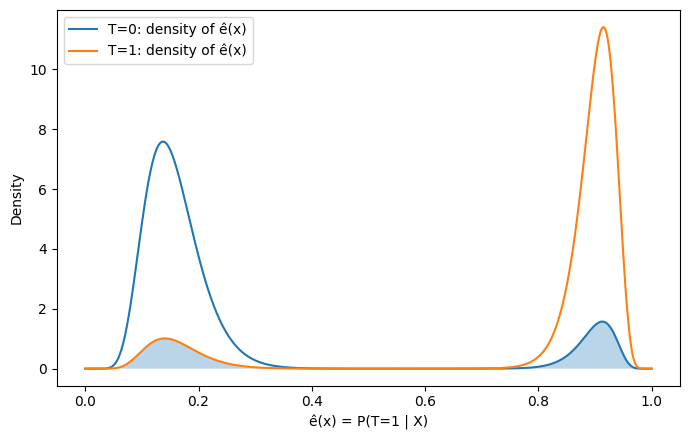

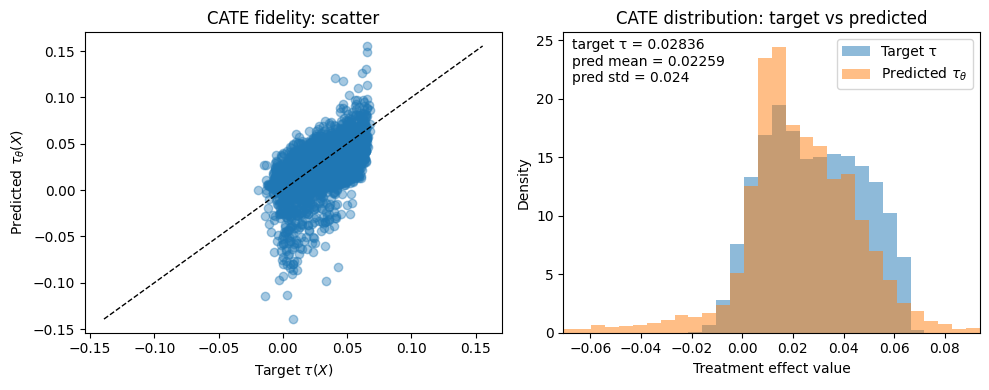

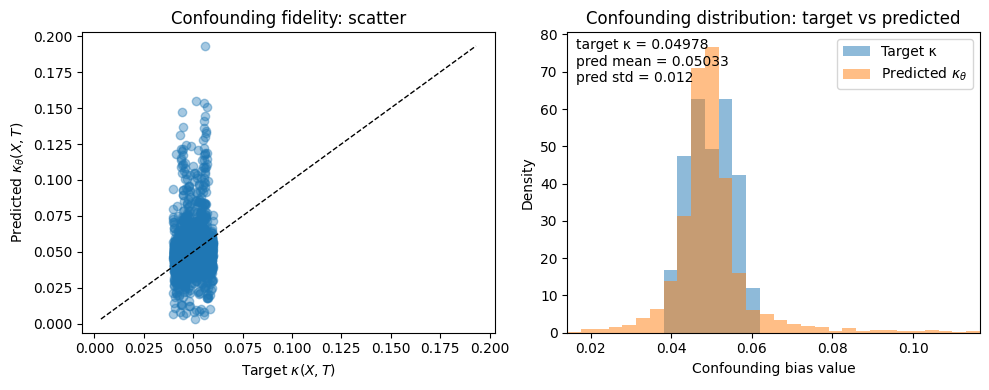

In [0]:
X_np = X_gen.detach().cpu().numpy() # shape (N, V)
T_np = T_tensor.detach().cpu().numpy().reshape(-1) # shape (N, )

# 3) Predicted τ and κ from m_post stats
tau_pred = stats["ite"].detach().cpu().numpy()      # shape [N, V] or [N]
kappa_pred = stats["bias"].detach().cpu().numpy()   # shape [N, V] or [N]
n_samples = tau_pred.shape[0]
# 4) Target τ(X), κ(X, T) from user’s functions f, g
#    (these are exactly your effect / bias functions passed to conVAE)

tau_pred = np.squeeze(tau_pred) # shape (N, )
kappa_pred = np.squeeze(kappa_pred) # shape (N, )

def _to_numpy(x):
    """Convert torch.Tensor or scalar to numpy array safely."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    else:
        return np.asarray(x)

index = VarIndex(X.columns.tolist())
tau_target = _to_numpy(model_po.f(X_gen, index))
kappa_target = _to_numpy(model_po.g(X_gen, T_tensor[:,0], index)) # shape of Tgen[:,0] is [N]

if tau_target.shape == ():
    tau_target = np.full(n_samples, float(tau_target))
else:
    tau_target = np.squeeze(tau_target)

if kappa_target.shape == ():
    kappa_target = np.full(n_samples, float(kappa_target))
else:
    kappa_target = np.squeeze(kappa_target)

ce = CausalEval(
    tau_pred=tau_pred,
    tau_target=tau_target,
    kappa_pred=kappa_pred,
    kappa_target=kappa_target,
    T=T_np,
    X=X_np
)

# 6) Collect everything
metrics = ce.all_metrics(plot = True)

In [0]:
# experiment of using ConVAE only
## Part 2: test treatment effect and unmeasured confounding functions
### 2.2: linear treatment effect function and constant unmeasured confounding value
# when overlap is moderate 
# def treatment_effect_fn(X, index):
#     cvd_pre, age= index.slice(X, "cvd_pre", "age", unbind=True)
#     # X is a torch.Tensor of features excluding 
#     bump = torch.exp(0.5*age) # cvd_pre
#     return 0.02+0.02* bump 

# option 1: peicewise function with continous term
# mean_age = mcrpc_data["age"].mean()
# std_age = mcrpc_data["age"].std()
# mean_cci = mcrpc_data["Charlson"].mean()
# std_cci = mcrpc_data["Charlson"].std()
# def treatment_effect_fn(X, index):
#     cvd_pre, age, Charlson = index.slice(X, "cvd_pre", "age", "Charlson", unbind=True)
#     I_age80 = (age >= (80-mean_age)/std_age).float()
#     out = 0.05+ 0.01 * cvd_pre + 0.01 * I_age80 + 0.01 * (cvd_pre * I_age80) + 0.01*Charlson
#     return out
    # results: the piecewise function works well after adding the continuous Charlson part
    # weight: mse: 0.2, 0.1; var: 2e-1, 2e-2

# option 2: simple terms
def treatment_effect_fn(X, index):
    cvd_pre, age, Charlson = index.slice(X, "cvd_pre", "age", "Charlson", unbind=True)
    out = 0.05+ 0.015 * cvd_pre + 0.01 * age + 0.01*Charlson
    return out
# works well
# weight: mse: 0.2, 0.1; var: 2e-1, 2e-2

def selection_bias_fn(X, T, index):
    # latent risk constructed from observable X
    return 0.02

model_po = conVAE(
            df=mcrpc_preprocessed,
            Xnames=["exp"] + X.columns.tolist(),
            Ynames=["hosp_ed_any"],
            binary_cols=binary_var,
            categorical_cols=categorical_var,      # QZ: list of categorical columns in Ynames
            categorical_dims=unique_levels,      # QZ: dict {col_name: num_classes}
            var_bounds=var_bounds,
            latent_dim= 1,
            hidden_dim=[64],
            potential_outcome=True,
            treatment_cols=["exp"],
            treatment_effect_fn=treatment_effect_fn,
            selection_bias_fn=selection_bias_fn,
            effect_rigidity=1e3,
            effect_mse_weight=0.2, # effect blend weight on MSE
            effect_var_weight=2e-1, # variance penalty for treatment effect residuals
            bias_rigidity=1e3,
            bias_mse_weight=0.1, # bias blend weight on MSE
            bias_var_weight=2e-2, # variance penalty for bias residuals
            kld_rigidity=0.1,
            overlap_weight=0.0,
        ) 
model_po.fit_model(accelerator='auto', precision='32-true', max_epochs=1000, limit_train_batches=0.5)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:45: UserWarning:

Attribute 'overlap_target' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['overlap_target'])`.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │     65 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │     65 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



In [0]:
# Last logged validation loss from the final epoch
last_val_po = model_po.trainer.callback_metrics.get("val_loss")
print("Last val_loss for outcome:", float(last_val_po) if last_val_po is not None else "N/A")
model_po.fit_bgmm_from_training_latents()
Ygen, Ymean, Ymean_prime, stats = model_po.generate_bgmm(x = torch.cat((X_gen, T_tensor), 1))

Last val_loss for outcome: 0.14923569560050964


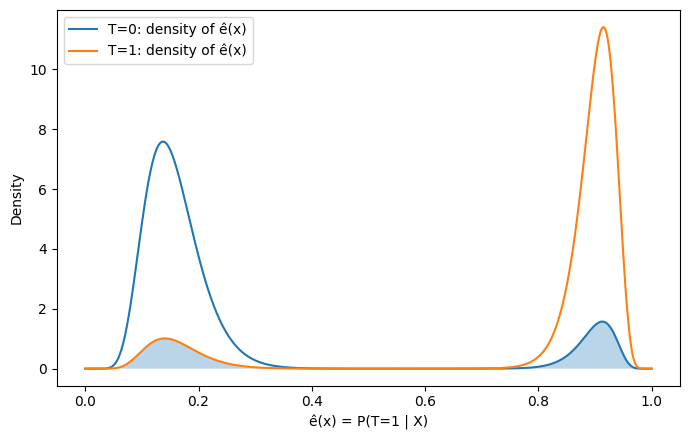

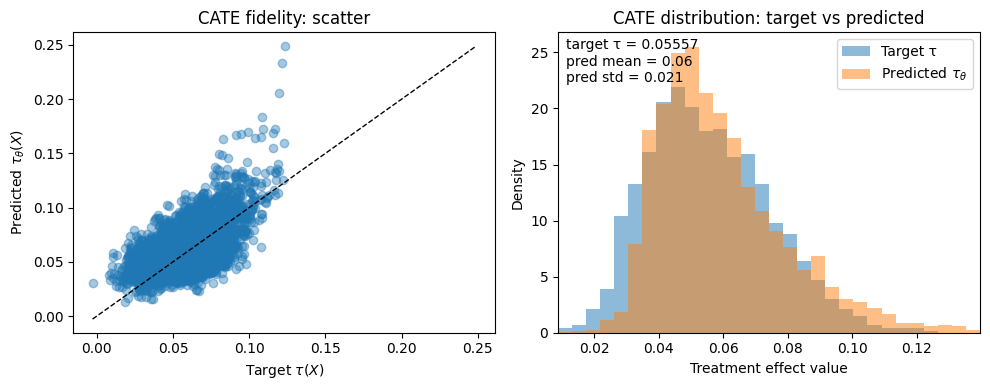

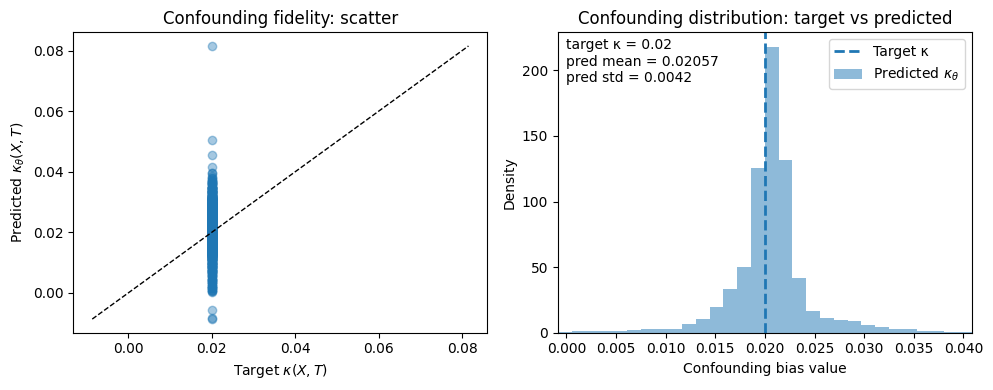

In [0]:
X_np = X_gen.detach().cpu().numpy() # shape (N, V)
T_np = T_tensor.detach().cpu().numpy().reshape(-1) # shape (N, )

# 3) Predicted τ and κ from m_post stats
tau_pred = stats["ite"].detach().cpu().numpy()      # shape [N, V] or [N]
kappa_pred = stats["bias"].detach().cpu().numpy()   # shape [N, V] or [N]
n_samples = tau_pred.shape[0]
# 4) Target τ(X), κ(X, T) from user’s functions f, g
#    (these are exactly your effect / bias functions passed to conVAE)

tau_pred = np.squeeze(tau_pred) # shape (N, )
kappa_pred = np.squeeze(kappa_pred) # shape (N, )

def _to_numpy(x):
    """Convert torch.Tensor or scalar to numpy array safely."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    else:
        return np.asarray(x)

index = VarIndex(X.columns.tolist())
tau_target = _to_numpy(model_po.f(X_gen, index))
kappa_target = _to_numpy(model_po.g(X_gen, T_tensor[:,0], index)) # shape of Tgen[:,0] is [N]

if tau_target.shape == ():
    tau_target = np.full(n_samples, float(tau_target))
else:
    tau_target = np.squeeze(tau_target)

if kappa_target.shape == ():
    kappa_target = np.full(n_samples, float(kappa_target))
else:
    kappa_target = np.squeeze(kappa_target)

ce = CausalEval(
    tau_pred=tau_pred,
    tau_target=tau_target,
    kappa_pred=kappa_pred,
    kappa_target=kappa_target,
    T=T_np,
    X=X_np
)

# 6) Collect everything
metrics = ce.all_metrics(plot = True)